# Observing a Bifrost simulation of the quiet Sun

This tutorial starts from a simulation ECLIPSE has no reader for. It takes a snapshot of the [Carlsson et al. (2016)](https://www.aanda.org/articles/aa/full_html/2016/01/aa27226-15/aa27226-15.html) Bifrost simulation of an enhanced network region, builds an [atmosphere file](../atmosphere-files/) from it in a few lines, synthesises Fe IX 171.073, and observes it with EUVST-SW: the intensity, the Doppler velocity and the velocity precision.

The simulation covers 24 x 24 Mm of quiet Sun and network from the convection zone to the corona, with its vertical grid stretching from 19 km in the photosphere to 100 km in the corona, and it carries its own electron density from non-equilibrium hydrogen ionisation. Fe IX 171.073 forms at about 0.8 MK and is the brightest line of the quiet corona in the short-wavelength channel.

## Before you start

| Resource | Needed |
| --- | --- |
| Download | 2.0 GB of simulation data |
| Disk | about 15 GB, mostly for the synthesis file |
| Memory | peaks near 100 GB |
| Wall clock | about 40 minutes on 64 cores, and the download on top; the 200 Monte Carlo iterations are most of it |

Contribution functions come from CHIANTI through [fiasco](https://fiasco.readthedocs.io/), which builds a local HDF5 copy of the database the first time it is used.

In [1]:
import astropy.units as u
import dill
import matplotlib.pyplot as plt
import numpy as np

from astropy.coordinates import SkyCoord
from astropy.io import fits
from matplotlib.colors import LogNorm
from pathlib import Path
from sunpy.map import Map

from euvst_response import (
    Atmosphere,
    edges_from_centres,
    write_atmosphere,
    load_instrument_response_results,
    get_results_for_combination,
    create_sunpy_maps_from_combo,
    summary_table,
)

SNAPSHOT = 385  # the first published snapshot of the run, at t = 3850 s

## 1. Get the simulation snapshot

The [Hinode Science Data Centre Europe](https://sdc.uio.no/search/simulations) publishes the simulation as FITS files, one variable per file, in SI units. Snapshot 385 is the first published one, at t = 3850 s. An optically thin calculation needs the temperature, the density and the velocity along the line of sight, which for the top-down view is the vertical velocity. This simulation also has an electron density, which is used instead of deriving one from the mass density.

| File | Quantity | Unit |
| --- | --- | --- |
| `BIFROST_en024048_hion_lgtg_385.fits` | log10 temperature | K |
| `BIFROST_en024048_hion_lgr_385.fits` | log10 mass density | kg m^-3 |
| `BIFROST_en024048_hion_lgne_385.fits` | log10 electron density | m^-3 |
| `BIFROST_en024048_hion_uz_385.fits` | vertical velocity | m s^-1 |

In [2]:
import subprocess

BASE = "https://sdc.uio.no/vol/simulations/en024048_hion/atmos"

for variable in ("lgtg", "lgr", "lgne", "uz"):
    name = f"BIFROST_en024048_hion_{variable}_{SNAPSHOT}.fits"
    path = Path("data/bifrost") / name
    path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["curl", "-sS", "-L", "-o", str(path), f"{BASE}/{name}"], check=True)
    print(f"{name}: {path.stat().st_size} bytes")

BIFROST_en024048_hion_lgtg_385.fits: 503991360 bytes
BIFROST_en024048_hion_lgr_385.fits: 503991360 bytes
BIFROST_en024048_hion_lgne_385.fits: 503991360 bytes
BIFROST_en024048_hion_uz_385.fits: 503991360 bytes


## 2. Build the atmosphere file

ECLIPSE reads any simulation from one HDF5 file holding the temperature, the density, the velocity and the positions of the cell boundaries, each with its unit. The cubes are `(nz, ny, nx)` with z pointing up, and velocities are positive towards increasing coordinate. These files already have that layout: the array in each is `(nz, ny, nx)`, z increases upwards, and the vertical grid, which is not uniform, is stored as cell centres in a FITS extension. `edges_from_centres` places the cell boundaries halfway between those centres.

The `lg` variables are base-10 logarithms, so they are raised to the power of ten as they are read.

In [3]:
def variable(name):
    """The cube, the header and the z cell centres of one variable."""
    with fits.open(f"data/bifrost/BIFROST_en024048_hion_{name}_{SNAPSHOT}.fits") as hdul:
        return hdul[0].data, hdul[0].header, hdul[1].data

lgtg, header, z_centres = variable("lgtg")
lgr, _, _ = variable("lgr")
lgne, _, _ = variable("lgne")
uz, _, _ = variable("uz")

nz, ny, nx = lgtg.shape
x_centres = (header["CRVAL1"] + (np.arange(nx) + 1 - header["CRPIX1"]) * header["CDELT1"]) * u.Mm
y_centres = (header["CRVAL2"] + (np.arange(ny) + 1 - header["CRPIX2"]) * header["CDELT2"]) * u.Mm

atmosphere = Atmosphere(
    temperature=10.0 ** lgtg.astype(np.float64) * u.K,
    mass_density=10.0 ** lgr.astype(np.float64) * u.kg / u.m**3,
    electron_density=10.0 ** lgne.astype(np.float64) * u.m**-3,
    velocity_z=uz * u.m / u.s,
    x_edges=edges_from_centres(x_centres),
    y_edges=edges_from_centres(y_centres),
    z_edges=edges_from_centres(z_centres * u.Mm),
    time=header["ELAPSED"] * u.s,
    source=f"Bifrost en024048_hion snapshot {SNAPSHOT}, Hinode SDC Europe",
)
write_atmosphere(atmosphere, "data/bifrost/en024048_hion_385.h5")
print(atmosphere.describe())

  Shape (nz, ny, nx): (496, 504, 504)
  x: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  y: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  z: -2.485 Mm to 14.416 Mm, cells from 0.0186 Mm to 0.0971 Mm
  Density: mass_density and electron_density
  Velocities: z
  Time: 3850.000 s
  Source: Bifrost en024048_hion snapshot 385, Hinode SDC Europe


`eclipse-atmosphere info` prints the same description of a file on disk, without loading its cubes.

In [4]:
!eclipse-atmosphere info data/bifrost/en024048_hion_385.h5

data/bifrost/en024048_hion_385.h5
  Shape (nz, ny, nx): (496, 504, 504)
  x: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  y: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  z: -2.485 Mm to 14.416 Mm, cells from 0.0186 Mm to 0.0971 Mm
  Density: mass_density and electron_density
  Velocities: z
  Time: 3850.000 s
  Source: Bifrost en024048_hion snapshot 385, Hinode SDC Europe


## 3. Synthesise the spectra

This step reads the atmosphere file, builds the VDEM, introduces the contribution function, and writes a synthesis file.

The box starts 2.4 Mm below the surface. `--crop-z` keeps the part from the surface up, which is where the line forms. `--integration-axis z` is the top-down view, so only the vertical velocity is needed; the vertical grid may be stretched for this view because it is integrated out cell by cell, while the two axes of the image have to be even.

In [5]:
!synthesise-spectra \
  --atmosphere data/bifrost/en024048_hion_385.h5 \
  --lines Fe09_171.0730 \
  --crop-z "0 Mm" "20 Mm" \
  --output-dir ./run/input \
  --output-name bifrost_network.pkl \
  --integration-axis z

STATIC MODE - Synthesis from an atmosphere file
  Atmosphere: data/bifrost/en024048_hion_385.h5
  Integration axis: z
  Velocity grid: +/-300.0 km / s at 5.0 km / s resolution
  Precision: <class 'numpy.float64'>
  Lines: ['Fe09_171.0730']
  Abundance: sun_coronal_2021_chianti
  Cropping: X=None, Y=None, Z=['0 Mm', '20 Mm']

Reading the atmosphere (18.42/540.81 GB)
  Shape (nz, ny, nx): (417, 504, 504)
  x: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  y: -0.024 Mm to 23.976 Mm, cells of 0.0476 Mm
  z: -0.010 Mm to 14.416 Mm, cells from 0.0186 Mm to 0.0971 Mm
  Density: mass_density and electron_density
  Velocities: z
  Time: 3850.000 s
  Source: Bifrost en024048_hion snapshot 385, Hinode SDC Europe
Electron density taken from the atmosphere
Computing contribution functions via fiasco (27.89/540.81 GB)
Computing G(T,N): 100%|██████████████████████████| 1/1 [01:03<00:00, 63.42s/ion]
  Fe09_171.0730: requested 171.0730 Angstrom, matched 171.0730 Angstrom (delta=0.0000 Angstrom)
  CHIANTI

Synthesis prints the requested and matched wavelength for the line. A large difference means CHIANTI has no such transition for that ion and a neighbouring one was picked up instead. See [naming spectral lines](../synthesis/#naming-spectral-lines).

Only the lines asked for are synthesised, so the spectrum holds Fe IX 171.073 alone. The real spectrum has fainter neighbours within the fitting window; they can be added to `--lines`.

## 4. The heliocentric intensity map

This is the simulation atmosphere before the instrument. It shows the emission integrated along the line of sight and across the line profile at the simulation resolution: the network lanes bright, the internetwork cells between them faint.

In [6]:
with open("run/input/bifrost_network.pkl", "rb") as f:
    synthesis = dill.load(f)

line_cube = synthesis["line_cubes"]["Fe09_171.0730"]
print(f"cube shape {line_cube.data.shape}, unit {line_cube.unit}")

cube shape (504, 504, 121), unit erg / (s sr cm3)


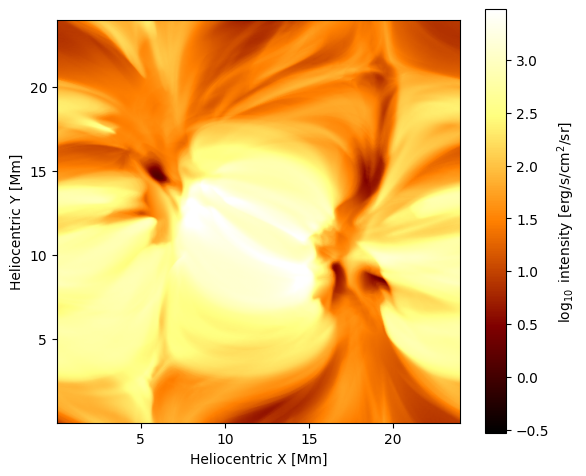

In [7]:
# Integrate the line profile. The cube is indexed (y, x, wavelength) and holds a
# spectral radiance, so the sum over the last axis needs the wavelength spacing.
cube = line_cube.to(u.erg / u.s / u.cm**2 / u.sr / u.cm)
wavelengths = cube.axis_world_coords(-1)[0].to(u.cm)
d_lambda = np.gradient(wavelengths)
intensity = (cube.data * d_lambda.value).sum(axis=-1) * u.erg / u.s / u.cm**2 / u.sr

y = line_cube.axis_world_coords(0)[0].to(u.Mm)
x = line_cube.axis_world_coords(1)[0].to(u.Mm)
high = np.percentile(np.log10(intensity.value[intensity.value > 0]), 99.5)
low = high - 4  # four decades below the brightest columns

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(
    np.log10(intensity.value),
    origin="lower",
    extent=[x[0].value, x[-1].value, y[0].value, y[-1].value],
    cmap="afmhot",
    vmin=low,
    vmax=high,
    aspect="equal",
)
ax.set_xlabel("Heliocentric X [Mm]")
ax.set_ylabel("Heliocentric Y [Mm]")
fig.colorbar(image, ax=ax, label=r"$\log_{10}$ intensity [erg/s/cm$^2$/sr]")
plt.show()


## 5. Simulate the instrument

`slit_width: 0.4 arcsec` sets both the slit and the raster step, and `expos: 40 s` is the exposure at each raster position. Both can be given as lists to sweep them (see [the configuration file reference](../instrument-response/#configuration-file)), but here they are single values.

`n_iter: 200` repeats the observation 200 times with independent noise. The spread of the fitted velocities across those repeats is the velocity precision. With no `fitting:` block, each spectrum is fitted with a single Gaussian.

In [8]:
%%writefile run/input/bifrost_network.yaml
instrument: SWC
synthesis_file: ./run/input/bifrost_network.pkl
reference_line: Fe09_171.0730

n_iter: 200
ncpu: -1
fit_signals: dn

simulation:
  slit_width: 0.4 arcsec
  expos: 40 s
  psf: True

detector:
  ccd_temperature: -60 Celsius

filter:
  c_thickness: 40 angstrom

Overwriting run/input/bifrost_network.yaml


In [9]:
!eclipse --config ./run/input/bifrost_network.yaml


  ______ _____ _      _____ _____   _____ ______
 |  ____/ ____| |    |_   _|  __ \ / ____|  ____|
 | |__ | |    | |      | | | |__) | (___ | |__
 |  __|| |    | |      | | |  ___/ \___ \|  __|
 | |___| |____| |____ _| |_| |     ____) | |____
 |______\_____|______|_____|_|    |_____/|______|

ECLIPSE: Emission Calculation and Line Prediction for SOLAR-C EUVST

Contact: James McKevitt (jm2@mssl.ucl.ac.uk). License: Contact for permission to use.

Running instrument response simulation with config: ./run/input/bifrost_network.yaml
------------------------------------------------------------
Fitting only 'dn' signal (skipping 'photon')
/gpfs/data/fs70652/jamesm/solar/wt-tutorials/euvst_response/main.py:472: UserWarning: The SWC PSF is the modelled PSF including simulations and some microroughness measurements. Final PSF will be measured before launch.
  warnings.warn(

Running 1 parameter combination(s).

Loading atmosphere...
Using 'Fe09_171.0730' as reference line for wavelength grid a

## 6. The maps as observed

`summary_table` lists every combination in the results file along with the exact parameter names. Use this before writing the `get_results_for_combination` call.

In [10]:
results = load_instrument_response_results("run/result/bifrost_network.pkl")
summary_table(results)

Software version : 0.9.0
Git commit       : 611ed204bffcc98a94cd083518808e32642fc162

detector.ccd_temperature | detector.dark_current    | detector.filter_distance | detector.gain_e_per_dn   | detector.material        | detector.max_dn          | detector.pix_size        | detector.plate_scale_angle | detector.qe_euv          | detector.qe_vis          | detector.read_noise_rms  | detector.wvl_res         | filter.al_thickness      | filter.c_thickness       | filter.mesh_throughput   | filter.oxide_thickness   | filter.table_thickness   | offchip_bin_slit         | simulation.enable_pinholes | simulation.expos         | simulation.instrument    | simulation.n_iter        | simulation.ncpu          | simulation.noise         | simulation.pinhole_positions_spectral | simulation.psf           | simulation.psf_boundary  | simulation.slit_width    | simulation.vis_sl        | telescope.D_ap           | telescope.microroughness_sigma | telescope.psf_params     | telescope.psf_type
--------

In [11]:
combination = get_results_for_combination(results, **{
    "simulation.slit_width": 0.4 * u.arcsec,
    "simulation.expos": 40 * u.s,
    "offchip_bin_slit": 1,
})

maps = create_sunpy_maps_from_combo(
    combination,
    data_type="dn",
    date_obs="2024-03-20T00:00:00",
)

print(sorted(maps))

['failed_fits', 'intensity_from_fit', 'intensity_mean', 'intensity_std', 'line_width_from_fit', 'line_width_mean', 'line_width_std', 'total_dn', 'total_photons', 'velocity_err', 'velocity_from_fit', 'velocity_mean', 'velocity_std', 'velocity_true']


Three maps from the same observation: the intensity the detector recorded, the Doppler velocity fitted to it, and the precision of that velocity. Velocity is positive away from the observer, so red is plasma moving down into the Sun and blue plasma moving up. The precision is the standard deviation of the fitted velocity over the 200 repeats: a few km/s where the line is bright, tens of km/s in the faint internetwork, where a 40 s exposure collects too few photons to place the line. The velocity is shown only where the precision is within 10 km/s, since elsewhere the fitted value is mostly noise.

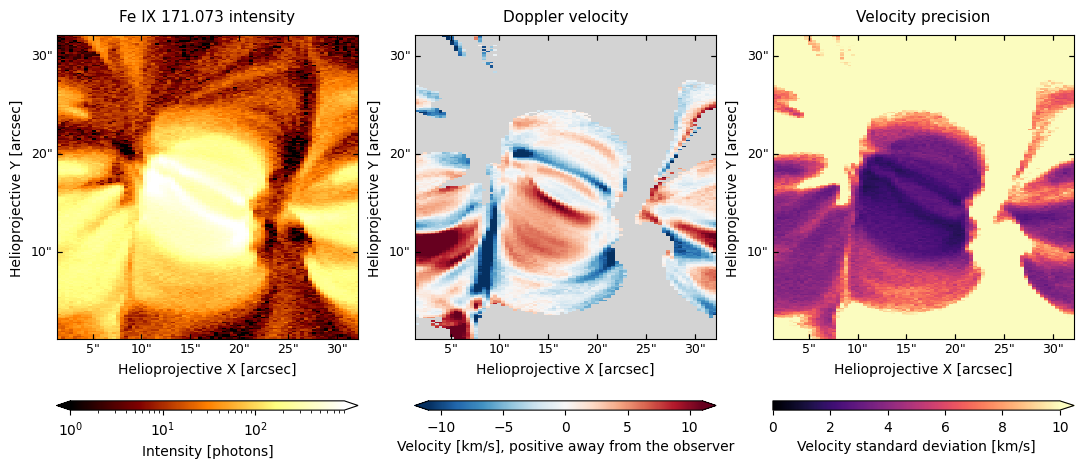

In [12]:
def frame(ax, m):
    """Show the map to 1 arcsec inside its edges, with ticks on every side."""
    ny, nx = m.data.shape
    corners = m.pixel_to_world([0, nx] * u.pix, [0, ny] * u.pix)
    padding = 1 * u.arcsec
    x0, y0 = m.world_to_pixel(SkyCoord(corners.Tx[0] + padding, corners.Ty[0] + padding,
                                       frame=m.coordinate_frame))
    x1, y1 = m.world_to_pixel(SkyCoord(corners.Tx[1] - padding, corners.Ty[1] - padding,
                                       frame=m.coordinate_frame))
    ax.set_xlim(x0.value, x1.value)
    ax.set_ylim(y0.value, y1.value)
    ax.set_frame_on(False)
    ax.grid(False)
    lon, lat = ax.coords
    for coord in (lon, lat):
        coord.set_ticks_visible(True)
        coord.set_ticks_position("all")
    ax.tick_params(axis="both", which="both", direction="in", labelsize=9, pad=3)
    lon.set_axislabel("Helioprojective X [arcsec]", fontsize=10)
    lat.set_axislabel("Helioprojective Y [arcsec]", fontsize=10)


PRECISION_LIMIT = 10  # km/s; velocities are shown where they are measured this well

photons = maps["total_photons"]
velocity = maps["velocity_mean"]
precision = maps["velocity_std"]

# The velocity map, only where the precision is within the limit.
measured = precision.data < PRECISION_LIMIT
velocity = Map(np.where(measured, velocity.data, np.nan), velocity.meta, plot_settings=velocity.plot_settings)

fig = plt.figure(figsize=(15, 4.6), layout="compressed")

ax = fig.add_subplot(131, projection=photons)
image = photons.plot(axes=ax, annotate=False, autoalign=False)
low, high = np.nanpercentile(photons.data[photons.data > 0], [1, 99.5])
image.set_norm(LogNorm(vmin=low, vmax=high))
image.cmap.set_bad(image.cmap(0))  # columns with no photons at all, drawn as the darkest colour
frame(ax, photons)
ax.set_title("Fe IX 171.073 intensity", fontsize=11, pad=10)
fig.colorbar(image, ax=ax, orientation="horizontal", extend="both", pad=0.08, aspect=32.5).set_label("Intensity [photons]")

ax = fig.add_subplot(132, projection=velocity)
image = velocity.plot(axes=ax, annotate=False, autoalign=False, cmap="RdBu_r")
limit = np.nanpercentile(np.abs(velocity.data), 95)
image.set_clim(-limit, limit)
image.cmap.set_bad("lightgrey")
frame(ax, velocity)
ax.set_title("Doppler velocity", fontsize=11, pad=10)
fig.colorbar(image, ax=ax, orientation="horizontal", extend="both", pad=0.08, aspect=32.5).set_label("Velocity [km/s], positive away from the observer")

ax = fig.add_subplot(133, projection=precision)
image = precision.plot(axes=ax, annotate=False, autoalign=False)
image.set_clim(0, PRECISION_LIMIT)
frame(ax, precision)
ax.set_title("Velocity precision", fontsize=11, pad=10)
fig.colorbar(image, ax=ax, orientation="horizontal", extend="max", pad=0.08, aspect=32.5).set_label("Velocity standard deviation [km/s]")

plt.show()


`create_sunpy_maps_from_combo` returns more than these three maps. `total_photons` is the signal before the detector and `total_dn` the same after it; `velocity_mean` and `velocity_std` are the mean and standard deviation of the fitted velocity across iterations; `velocity_from_fit` is the first fit of the first iteration, and `velocity_err` its difference from the known truth. They are ordinary SunPy maps, so all the SunPy map functions can be used.

From here, the same snapshot can be observed with a narrower slit or a shorter exposure by changing the configuration, or through the side of the box with `--integration-axis x` and `velocity_x` added to the atmosphere file; and the run's 157 later snapshots, 10 s apart, are there for anyone wanting to follow the network evolve.